<a href="https://colab.research.google.com/github/WVF-1/FULPs-Framework-CA-Application/blob/main/FULPs_CA_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs CA — v1
**Applying the FULPs Framework to Conway's Game of Life**

Author: William V. Fullerton  
Conscientiâ Research Group

---

### Experiment Summary
Each cell in a 50×50 toroidal Conway's Game of Life grid maintains a Laplace-smoothed
frequency-count table over its 512 possible neighbourhood configurations, augmented with
FULPs architectural components, and learns to predict its own survival outcome online
across 25 timesteps — compared against a plain table baseline with no FULPs components.

### Architecture
IDF (9-dim) → VoidStabilizer (9→16→9, frozen) → DSC + ARE → Frequency Table (512 states, Laplace-smoothed)

### FULPs-to-Cell Mapping
| Component | FULP | Role |
|-----------|------|------|
| IDF | 1 | Generates structureless 9-dim void samples |
| VoidStabilizer + EA | 1 | Learns void baseline; frozen after Stage 0 |
| DSC | 2 | Per-cell deviation from void (reconstruction error) |
| Void Tether | 1 (persistent) | Monitors void calibration across all timesteps |
| ARE (dual-buffer EMA) | 5 | Margin tracking, curiosity weighting, contradiction detection |
| Frequency Table | 3 | Pattern compression over 512-state neighbourhood space |

### Parameters (preserved from v4)
- IDF priors: `mu~N(0,0.02)`, `sig~U(0.05,0.30)`, `rho~U(-0.2,0.2)`
- EA: `target_std=0.3`, `λ_EA=0.5`
- VT: `λ_VT=0.05`
- ARE: threshold `0.20→0.05` (linear decay), `CONF_GATE=0.3`, buffer delay=10 timesteps
- 30 runs, seeds 42–71, batch CSV every 5 runs

### Hypotheses
- **A**: Cells in stable regions converge to lower prediction error faster than unstable cells.
- **B**: Cells in stable regions achieve lower final prediction error than unstable cells.
- **C**: Cells in unstable regions achieve greater state-space coverage but lower per-state accuracy due to transient configurations. FULPs curiosity weighting may attenuate the accuracy penalty.

### What to watch for in single run
1. DSC distributions clearly separated (IDF void < CA neighbourhoods)
2. DSC threshold calibrated meaningfully (non-trivial value)
3. Contradiction rate near 0 until timestep 10 (buffer delay), then rises non-monotonically
4. Online accuracy exceeds 0.7 by timestep 10
5. Table accuracy approaches 0.85+ by timestep 25
6. Stable cells show higher final table accuracy than unstable cells
7. VT signal remains stable across all 25 timesteps (void calibration held)

In [ ]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', '--quiet'])
print('Done.')

Done.


In [ ]:
# ── Cell 2: Imports and Configuration ────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.linalg import cholesky
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

# ── Grid ──────────────────────────────────────────────────────────────────────
GRID_H       = 50
GRID_W       = 50
N_TIMESTEPS  = 25

# ── Neighbourhood ─────────────────────────────────────────────────────────────
NBR_DIM      = 9       # 8 neighbours + own state
N_STATES     = 512     # 2^9 possible neighbourhood configurations

# ── VoidStabilizer (all params preserved exactly from v4) ─────────────────────
VOID_HIDDEN   = 16
EA_TARGET_STD = 0.3
EA_WEIGHT     = 0.5
VOID_EPOCHS   = 100
VOID_BATCH    = 256

# ── Void Tether (preserved from v4) ──────────────────────────────────────────
VT_WEIGHT     = 0.05

# ── ARE (all params preserved from v4, mapped to timestep domain) ─────────────
CONTRA_START     = 0.20    # Initial contradiction threshold (broad)
CONTRA_END       = 0.05    # Final contradiction threshold (tight)
CONF_GATE        = 0.3     # min max(pos_sim, neg_sim) for contradiction to fire
BUFFER_DELAY     = 10      # timesteps before ARE buffers activate (epoch>10 in v4)
EMA_ALPHA        = 0.1     # exponential moving average decay for ARE buffers
CURIOSITY_WEIGHT = 2.0     # weight multiplier for contradictory observations

# ── Multi-run ─────────────────────────────────────────────────────────────────
N_RUNS     = 30
BATCH_SIZE = 5
BASE_SEED  = 42
OUT_DIR    = '/content'

# ── Analysis ──────────────────────────────────────────────────────────────────
STABLE_MAX_CHANGES = 2     # cells changing state ≤ N times are 'stable'
REP_DIM = VOID_HIDDEN      # ARE representation dimension = VoidStabilizer latent dim

print('Configuration ready.')
print(f'  Grid: {GRID_H}x{GRID_W}  |  Timesteps: {N_TIMESTEPS}  |  States: {N_STATES}')
print(f'  VOID_HIDDEN={VOID_HIDDEN}  EA_target_std={EA_TARGET_STD}  lambda_EA={EA_WEIGHT}')
print(f'  lambda_VT={VT_WEIGHT}')
print(f'  ARE: threshold {CONTRA_START}->{CONTRA_END}  CONF_GATE={CONF_GATE}  '
      f'buffer_delay={BUFFER_DELAY}  curiosity={CURIOSITY_WEIGHT}')
print(f'  Multi-run: {N_RUNS} runs, batch checkpoint every {BATCH_SIZE}')

Configuration ready.
  Grid: 50x50  |  Timesteps: 25  |  States: 512
  VOID_HIDDEN=16  EA_target_std=0.3  lambda_EA=0.5
  lambda_VT=0.05
  ARE: threshold 0.2->0.05  CONF_GATE=0.3  buffer_delay=10  curiosity=2.0
  Multi-run: 30 runs, batch checkpoint every 5


In [ ]:
# ── Cell 3: Conway's Game of Life ─────────────────────────────────────────────
def tick(grid):
    """
    Single Game of Life step on a toroidal grid.
    Rules:
      - Live cell with <2 or >3 live neighbours dies (underpopulation / overpopulation)
      - Live cell with 2 or 3 live neighbours survives
      - Dead cell with exactly 3 live neighbours becomes alive (reproduction)
    Toroidal: edges wrap around.
    """
    H, W = grid.shape
    nbr_count = np.zeros((H, W), dtype=np.int8)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            nbr_count += np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    next_grid = np.zeros((H, W), dtype=np.int8)
    alive = grid == 1
    next_grid[alive  & ((nbr_count == 2) | (nbr_count == 3))] = 1
    next_grid[~alive & (nbr_count == 3)] = 1
    return next_grid


def population(grid):
    return int(grid.sum())


# Quick sanity check — glider should persist
_test = np.zeros((10, 10), dtype=np.int8)
_test[1,2]=_test[2,3]=_test[3,1]=_test[3,2]=_test[3,3] = 1
_after = tick(_test)
print("Conway's Game of Life defined (toroidal).")
print(f'  Glider sanity check: pop before={population(_test)}, after={population(_after)} (expect 5)')

Conway's Game of Life defined (toroidal).
  Glider sanity check: pop before=5, after=5 (expect 5)


In [ ]:
# ── Cell 4: Inner Depth Field (9-dimensional) ─────────────────────────────────
class InnerDepthField:
    """
    IDF — FULP 1: Void Awareness environment generator.
    Adapted from v4 for 9-dimensional neighbourhood space (from seq_len=50).

    Bayesian noise sampling + Gaussian copula prevent memorising any single
    silence distribution. Forces VoidStabilizer to learn 'structurelessness'
    as an abstract property rather than a specific noise signature.

    Priors preserved exactly from v4:
      mu  ~ N(0, 0.02)
      sig ~ U(0.05, 0.30)
      rho ~ U(-0.2, 0.2)
    Cholesky fallback on decomposition failure (unchanged from v4).
    """
    def __init__(self, seq_len=NBR_DIM):
        self.seq_len = seq_len

    def _corr_matrix(self, rho):
        idx = np.arange(self.seq_len)
        C   = rho ** np.abs(idx[:, None] - idx[None, :])
        return C + np.eye(self.seq_len) * 1e-6

    def sample(self, n):
        X = np.zeros((n, self.seq_len))
        for i in range(n):
            mu  = np.random.normal(0, 0.02)
            sig = np.random.uniform(0.05, 0.30)
            rho = np.random.uniform(-0.2, 0.2)
            try:
                L    = cholesky(self._corr_matrix(rho), lower=True)
                X[i] = mu + sig * (L @ np.random.normal(0, 1, self.seq_len))
            except Exception:
                X[i] = np.random.normal(mu, sig, self.seq_len)
        return X

    def sample_tensor(self, n):
        return torch.FloatTensor(self.sample(n).astype(np.float32))


IDF = InnerDepthField(seq_len=NBR_DIM)
print('IDF defined (9-dimensional).')
print(f'  Priors: mu~N(0,0.02)  sig~U(0.05,0.30)  rho~U(-0.2,0.2)')
print(f'  Sample shape check: {IDF.sample(4).shape}  (expect (4,9))')

IDF defined (9-dimensional).
  Priors: mu~N(0,0.02)  sig~U(0.05,0.30)  rho~U(-0.2,0.2)
  Sample shape check: (4, 9)  (expect (4,9))


In [ ]:
# ── Cell 5: VoidStabilizer (9->16->9) ─────────────────────────────────────────
class VoidStabilizer(nn.Module):
    """
    VoidStabilizer — FULP 1.
    Adapted for 9-dimensional neighbourhood input (v4 used seq_len=50).
    Architecture: 9 -> VOID_HIDDEN=16 -> 9

    All parameters preserved from v4:
      EA_TARGET_STD = 0.3   (targets activation std, not mean — the v3 fix)
      EA_WEIGHT     = 0.5
      VT_WEIGHT     = 0.05

    Adaptation note:
      The v4 FULPsSystem pipeline was:
        IDF -> VoidStabilizer -> PertEncoder -> PatExtractor -> ARE -> EPL
      In the CA, there is no PertEncoder, PatExtractor, or EPL.
      The VoidStabilizer encoder output (16-dim latent) IS the representation
      for the ARE. The frequency table replaces EPL.

    What to watch for in Stage 0 training:
      - recon loss should decrease from ~0.06 toward ~0.03
      - EA loss should be non-zero from epoch 0 and converge toward 0
      - If EA reads 0.0000 throughout: activation std has collapsed (bad)
    """
    def __init__(self, seq_len=NBR_DIM, hidden_dim=VOID_HIDDEN,
                 ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT):
        super().__init__()
        self.ea_target_std = ea_target_std
        self.ea_weight     = ea_weight
        self.encoder       = nn.Sequential(nn.Linear(seq_len, hidden_dim), nn.Tanh())
        self.decoder       = nn.Linear(hidden_dim, seq_len)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x):
        """Return latent representation for ARE (16-dim)."""
        return self.encoder(x)

    def dsc(self, x):
        """Deviant Signal Channel: per-sample reconstruction error (FULP 2)."""
        x_hat, _ = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=1)

    def void_tether(self, idf, n=64):
        """Persistent Void Constraint: mean DSC on fresh IDF samples (FULP 1)."""
        with torch.no_grad():
            x_void = idf.sample_tensor(n)
        return float(self.dsc(x_void).mean().item())

    def training_loss(self, x):
        x_hat, z   = self.forward(x)
        recon_loss = nn.MSELoss()(x_hat, x)
        ea_loss    = (z.std() - self.ea_target_std) ** 2
        total      = recon_loss + self.ea_weight * ea_loss
        return total, recon_loss.item(), ea_loss.item()


def train_void_stabilizer(void_model, idf, n_epochs=VOID_EPOCHS,
                           batch_size=VOID_BATCH, lr=1e-3, verbose=True):
    opt     = torch.optim.Adam(void_model.parameters(), lr=lr)
    history = {'total': [], 'recon': [], 'ea': []}
    for epoch in range(n_epochs):
        x_void = idf.sample_tensor(batch_size)
        total, recon, ea = void_model.training_loss(x_void)
        opt.zero_grad(); total.backward(); opt.step()
        history['total'].append(total.item())
        history['recon'].append(recon)
        history['ea'].append(ea)
        if verbose and epoch % 25 == 0:
            print(f'    [Void {epoch:3d}]  total={total.item():.4f}  '
                  f'recon={recon:.4f}  EA={ea:.4f}')
    return history


print('VoidStabilizer defined (9->16->9).')

VoidStabilizer defined (9->16->9).


STAGE 0: Void Stabilization
    [Void   0]  total=0.0740  recon=0.0705  EA=0.0070
    [Void  25]  total=0.0451  recon=0.0419  EA=0.0064
    [Void  50]  total=0.0319  recon=0.0292  EA=0.0055
    [Void  75]  total=0.0266  recon=0.0248  EA=0.0037

VoidStabilizer frozen. DSC + VT operational.
  Final recon loss : 0.0194
  Final EA loss    : 0.0023
  (Non-zero EA confirms std-targeting correction is working)


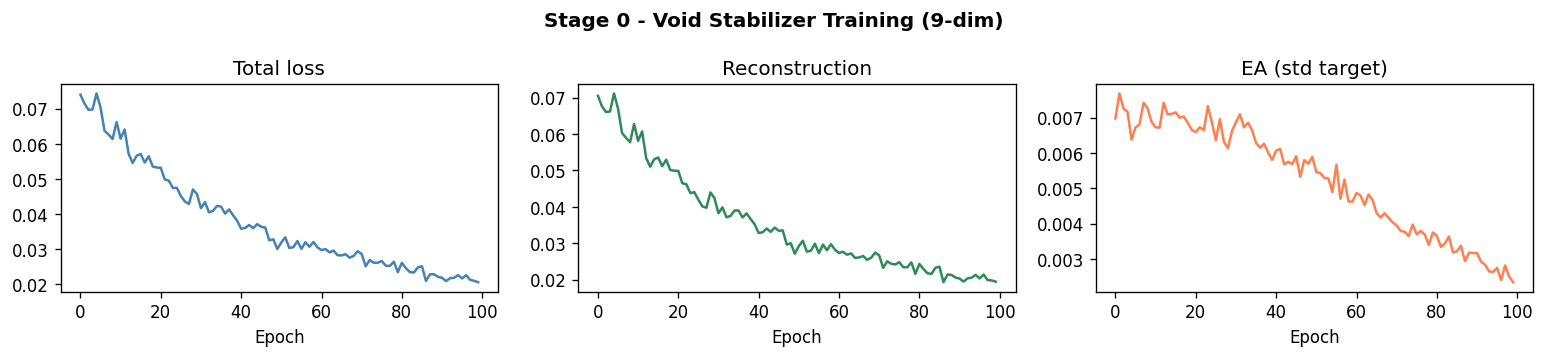

Saved: fulps_ca_void_training.png


In [ ]:
# ── Cell 6: Stage 0 — Void Stabilization ─────────────────────────────────────
# The VoidStabilizer is trained ONCE here on IDF samples (no CA data involved).
# It is reused across all 30 runs. This is valid because the IDF is independent
# of the CA — it generates structureless noise regardless of grid state.
print('=' * 60)
print('STAGE 0: Void Stabilization')
print('=' * 60)

torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

void_model = VoidStabilizer(
    seq_len=NBR_DIM, hidden_dim=VOID_HIDDEN,
    ea_target_std=EA_TARGET_STD, ea_weight=EA_WEIGHT
)

void_history = train_void_stabilizer(
    void_model, IDF, n_epochs=VOID_EPOCHS, batch_size=VOID_BATCH,
    lr=1e-3, verbose=True
)

# Freeze permanently — weights never change again
for p in void_model.parameters():
    p.requires_grad = False
void_model.eval()

print('\nVoidStabilizer frozen. DSC + VT operational.')
print(f'  Final recon loss : {void_history["recon"][-1]:.4f}')
print(f'  Final EA loss    : {void_history["ea"][-1]:.4f}')
print(f'  (Non-zero EA confirms std-targeting correction is working)')

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
fig.suptitle('Stage 0 - Void Stabilizer Training (9-dim)', fontweight='bold')
for ax, key, col, lbl in zip(
    axes,
    ['total', 'recon', 'ea'],
    ['steelblue', 'seagreen', 'coral'],
    ['Total loss', 'Reconstruction', 'EA (std target)']
):
    ax.plot(void_history[key], color=col)
    ax.set_title(lbl); ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulps_ca_void_training.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fulps_ca_void_training.png')

DSC THRESHOLD CALIBRATION
  IDF DSC   : mean=0.0199  std=0.0193
  CA  DSC   : mean=0.1291  std=0.0974
  DSC threshold (25th pct of CA) : 0.0526
  Distribution separation: OK - IDF DSC < CA DSC


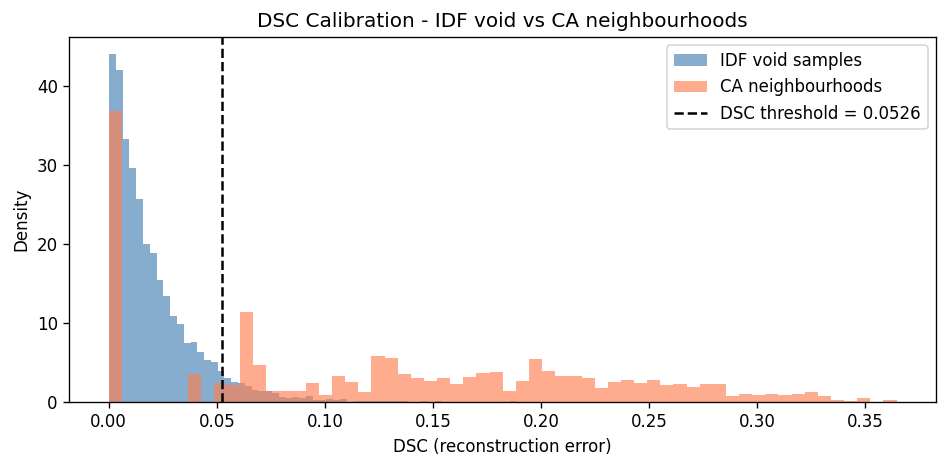

Saved: fulps_ca_dsc_calibration.png


In [ ]:
# ── Cell 7: DSC Threshold Calibration ────────────────────────────────────────
# Run a short calibration pass to determine the DSC threshold.
# Threshold = 25th percentile of DSC values from actual CA neighbourhoods.
# Below threshold: neighbourhood looks void-like -> ARE curiosity does NOT fire.
# Above threshold: neighbourhood is structured -> ARE curiosity is permitted to act.
# This preserves full updates for void-like states while amplifying structured contradictions.
print('=' * 60)
print('DSC THRESHOLD CALIBRATION')
print('=' * 60)

np.random.seed(0)
cal_grid = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)

all_ca_dsc = []
shifts = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]

for _ in range(5):
    channels = np.zeros((GRID_H, GRID_W, 9), dtype=np.float32)
    for k, (di, dj) in enumerate(shifts):
        channels[:, :, k] = np.roll(
            np.roll(cal_grid, -di, axis=0), -dj, axis=1
        ).astype(np.float32)
    nbr_t = torch.FloatTensor(channels.reshape(-1, NBR_DIM))
    with torch.no_grad():
        dsc_vals = void_model.dsc(nbr_t).numpy()
    all_ca_dsc.append(dsc_vals)
    cal_grid = tick(cal_grid)

all_ca_dsc = np.concatenate(all_ca_dsc)

# IDF reference distribution
x_idf_ref = IDF.sample_tensor(5000)
with torch.no_grad():
    idf_dsc_ref = void_model.dsc(x_idf_ref).numpy()

DSC_THRESHOLD = float(np.percentile(all_ca_dsc, 25))

print(f'  IDF DSC   : mean={idf_dsc_ref.mean():.4f}  std={idf_dsc_ref.std():.4f}')
print(f'  CA  DSC   : mean={all_ca_dsc.mean():.4f}  std={all_ca_dsc.std():.4f}')
print(f'  DSC threshold (25th pct of CA) : {DSC_THRESHOLD:.4f}')

separation_ok = idf_dsc_ref.mean() < all_ca_dsc.mean()
print(f'  Distribution separation: {"OK - IDF DSC < CA DSC" if separation_ok else "WARNING: no separation"}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(idf_dsc_ref, bins=60, alpha=0.65, color='steelblue',
        label='IDF void samples', density=True)
ax.hist(all_ca_dsc,  bins=60, alpha=0.65, color='coral',
        label='CA neighbourhoods', density=True)
ax.axvline(DSC_THRESHOLD, color='black', linestyle='--', lw=1.5,
           label=f'DSC threshold = {DSC_THRESHOLD:.4f}')
ax.set_xlabel('DSC (reconstruction error)')
ax.set_ylabel('Density')
ax.set_title('DSC Calibration - IDF void vs CA neighbourhoods')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fulps_ca_dsc_calibration.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fulps_ca_dsc_calibration.png')

In [ ]:
# ── Cell 8: Grid and Neighbourhood Utilities (Adaptive FULPs Version) ─────────

# ==========================================================
# 1. Precompute GoL truth table for all 512 neighbourhoods
# ==========================================================

def precompute_gol_truth():
    truth = np.zeros(N_STATES, dtype=np.int8)

    for state in range(N_STATES):
        bits = np.array([(state >> k) & 1 for k in range(9)], dtype=np.int8)

        own = bits[4]
        n_nbrs = bits.sum() - own

        if own == 1:
            truth[state] = 1 if n_nbrs in [2, 3] else 0
        else:
            truth[state] = 1 if n_nbrs == 3 else 0

    return truth.astype(np.int8)


GOL_TRUTH = precompute_gol_truth()

print(f"GoL truth precomputed: {GOL_TRUTH.sum()} / {N_STATES} states produce live outcome")
print(f"({GOL_TRUTH.sum()/N_STATES*100:.1f}% live outcomes — confirms death-bias)")

# ==========================================================
# 2. Precomputed indexing arrays
# ==========================================================

_II = np.arange(GRID_H)[:, None]
_JJ = np.arange(GRID_W)[None, :]

_POWERS = (2 ** np.arange(9)).astype(np.int32)

_SHIFTS = [
    (-1,-1), (-1,0), (-1,1),
    ( 0,-1), ( 0,0), ( 0,1),
    ( 1,-1), ( 1,0), ( 1,1)
]

# ==========================================================
# 3. Threshold configuration
# ==========================================================

BASE_THRESHOLD = 0.70
CONTRA_THRESHOLD = 0.60

# ==========================================================
# 4. Encode neighbourhoods
# ==========================================================

def encode_neighbourhoods(grid):
    """
    Returns:
        indices : [H,W] int32  encoded neighbourhood state
        floats  : [H,W,9] float32  binary neighbourhood channels
    """
    channels = np.zeros((GRID_H, GRID_W, 9), dtype=np.float32)

    for k, (di, dj) in enumerate(_SHIFTS):
        channels[:, :, k] = np.roll(
            np.roll(grid, -di, axis=0),
            -dj,
            axis=1
        ).astype(np.float32)

    indices = (channels.astype(np.int32) * _POWERS[None, None, :]).sum(axis=-1)

    return indices.astype(np.int32), channels

# ==========================================================
# 5. Adaptive prediction function
# ==========================================================

def predict_from_table(table, nbr_indices, contradiction_mask=None):
    """
    Predict next state from local rule table.

    table              : [H,W,512,2]
    nbr_indices        : [H,W]
    contradiction_mask : [H,W] bool or None

    Returns:
        preds : [H,W] int8
    """

    counts = table[_II, _JJ, nbr_indices]       # [H,W,2]
    total = counts.sum(axis=-1)                 # [H,W]

    p_survive = counts[...,1] / np.maximum(total, 1)

    # Default threshold
    threshold = np.full((GRID_H, GRID_W), BASE_THRESHOLD, dtype=np.float32)

    # Lower threshold for contradiction cells
    if contradiction_mask is not None:
        threshold = np.where(contradiction_mask, CONTRA_THRESHOLD, BASE_THRESHOLD)

    preds = (p_survive > threshold).astype(np.int8)

    return preds

# ==========================================================
# 6. Table accuracy across all 512 states
# ==========================================================

def table_accuracy_grid(table, gol_truth=GOL_TRUTH):
    probs = table[...,1] / np.maximum(table.sum(axis=-1), 1)
    preds = (probs > BASE_THRESHOLD).astype(np.int8)

    correct = (preds == gol_truth[None,None,:])

    return correct.mean(axis=-1).astype(np.float32)

# ==========================================================
# 7. Coverage metric
# ==========================================================

def table_coverage_grid(table):
    observed = (table.max(axis=-1) > 1.0)
    return observed.mean(axis=-1).astype(np.float32)

# ==========================================================
# 8. Accuracy over observed states only
# ==========================================================

def per_state_accuracy_grid(table, gol_truth=GOL_TRUTH):
    observed = (table.max(axis=-1) > 1.0)

    probs = table[...,1] / np.maximum(table.sum(axis=-1), 1)
    preds = (probs > BASE_THRESHOLD).astype(np.int8)

    correct = (preds == gol_truth[None,None,:]) & observed

    n_obs = observed.sum(axis=-1)

    acc = np.where(
        n_obs > 0,
        correct.sum(axis=-1) / np.maximum(n_obs, 1),
        np.nan
    )

    return acc.astype(np.float32)

# ==========================================================
# 9. Stable-cell detection
# ==========================================================

def detect_stable_cells(state_history, max_changes=STABLE_MAX_CHANGES):
    n_changes = np.sum(
        np.abs(np.diff(state_history.astype(np.int16), axis=0)),
        axis=0
    )

    return (n_changes <= max_changes)

# ==========================================================
# 10. Summary
# ==========================================================

print("Adaptive grid utilities defined.")
print(f"BASE_THRESHOLD   = {BASE_THRESHOLD}")
print(f"CONTRA_THRESHOLD = {CONTRA_THRESHOLD}")
print("FULPs now changes prediction boundaries, not just confidence.")

GoL truth precomputed: 140 / 512 states produce live outcome
(27.3% live outcomes — confirms death-bias)
Adaptive grid utilities defined.
BASE_THRESHOLD   = 0.7
CONTRA_THRESHOLD = 0.6
FULPs now changes prediction boundaries, not just confidence.


In [ ]:
# ── Cell 9: FULPs State — Tables and ARE ─────────────────────────────────────

def init_tables():
    """
    Initialise per-cell frequency-count tables with Laplace smoothing.
    All counts start at 1.0, preventing undefined predictions at t=0.
    Shape: [H, W, 512, 2]  where dim -1 is [death_count, survival_count].
    """
    return np.ones((GRID_H, GRID_W, N_STATES, 2), dtype=np.float32)


def init_are_state():
    """
    Initialise per-cell ARE dual-buffer state (EMA variant).
    Replaces the rolling-buffer approach from v4 with EMA for online CA setting.

    Buffers store the exponential moving average of neighbourhood representations
    (16-dim VoidStabilizer latent vectors) for each class (survive / die).
    'active' flags prevent contradiction detection before first class observation.
    """
    return {
        'pos_rep'    : np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
        'neg_rep'    : np.zeros((GRID_H, GRID_W, REP_DIM), dtype=np.float32),
        'pos_active' : np.zeros((GRID_H, GRID_W), dtype=bool),
        'neg_active' : np.zeros((GRID_H, GRID_W), dtype=bool),
    }


def compute_are_margin(reps_flat, are_state, threshold):
    """
    Compute ARE margin and contradiction flags for all cells.

    margin = cosine_sim(rep, pos_buf) - cosine_sim(rep, neg_buf)
    Contradiction fires when:
      |margin| < threshold  AND
      max(pos_sim, neg_sim) > CONF_GATE  AND
      both buffers are populated

    This is the per-cell analog of the v4 Stage 3 contradiction logic.
    Contradiction revision (backward pass) is deferred — the FULP 5 signal
    (margin + curiosity weight) is active; the recursive rules component is not.

    reps_flat : [H*W, REP_DIM]
    returns   : margin [H,W], contra_flags [H,W], pos_sim [H,W], neg_sim [H,W]
    """
    rep   = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)
    p_rep = are_state['pos_rep']    # [H, W, REP_DIM]
    n_rep = are_state['neg_rep']

    def cos_sim_hw(a, b):
        dot    = np.sum(a * b, axis=-1)
        norm_a = np.linalg.norm(a, axis=-1)
        norm_b = np.linalg.norm(b, axis=-1)
        denom  = norm_a * norm_b
        denom  = np.where(denom > 1e-8, denom, 1e-8)
        return dot / denom

    pos_sim = cos_sim_hw(rep, p_rep)    # [H, W]
    neg_sim = cos_sim_hw(rep, n_rep)

    # Zero out where buffer not yet populated
    pos_sim = np.where(are_state['pos_active'], pos_sim, 0.0)
    neg_sim = np.where(are_state['neg_active'], neg_sim, 0.0)

    margin      = pos_sim - neg_sim
    both_active = are_state['pos_active'] & are_state['neg_active']
    max_sim     = np.maximum(pos_sim, neg_sim)

    contra_flags = (
        (np.abs(margin) < threshold) &
        (max_sim > CONF_GATE) &
        both_active
    )
    return margin, contra_flags, pos_sim, neg_sim


def update_are_buffers(are_state, reps_flat, outcomes):
    """
    EMA update of per-cell dual buffers.
    Only updates a cell's buffer for the class it actually observed this timestep.
    reps_flat : [H*W, REP_DIM]
    outcomes  : [H, W] int8 (0=death, 1=survival)
    """
    rep = reps_flat.reshape(GRID_H, GRID_W, REP_DIM)

    mask_pos = (outcomes == 1)
    if mask_pos.any():
        are_state['pos_rep'][mask_pos] = (
            (1 - EMA_ALPHA) * are_state['pos_rep'][mask_pos] +
            EMA_ALPHA * rep[mask_pos]
        )
        are_state['pos_active'][mask_pos] = True

    mask_neg = (outcomes == 0)
    if mask_neg.any():
        are_state['neg_rep'][mask_neg] = (
            (1 - EMA_ALPHA) * are_state['neg_rep'][mask_neg] +
            EMA_ALPHA * rep[mask_neg]
        )
        are_state['neg_active'][mask_neg] = True


def update_tables(fulps_table, base_table, nbr_indices, outcomes, cw):
    """
    Update per-cell frequency tables.
    FULPs table: curiosity-weighted (1.0 normally, 2.0 on contradiction + DSC gate).
    Base table:  uniform weight 1.0 (no FULPs components).
    Each (i,j) cell maps to a unique index — no duplicate conflict in += .
    """
    outcome_int = outcomes.astype(int)
    fulps_table[_II, _JJ, nbr_indices, outcome_int] += cw
    base_table[ _II, _JJ, nbr_indices, outcome_int] += 1.0


print('FULPs state utilities defined.')
print('  init_tables, init_are_state, compute_are_margin,')
print('  update_are_buffers, update_tables')

FULPs state utilities defined.
  init_tables, init_are_state, compute_are_margin,
  update_are_buffers, update_tables


In [ ]:
# ── Cell 10: Simulation Engine (Adaptive Threshold FULPs Version) ────────────

def run_simulation(seed, void_model, idf, dsc_threshold,
                   is_single_run=False, verbose=False):

    np.random.seed(seed)
    torch.manual_seed(seed)

    grid        = np.random.randint(0, 2, size=(GRID_H, GRID_W), dtype=np.int8)
    fulps_table = init_tables()
    base_table  = init_tables()
    are_state   = init_are_state()

    state_history = np.zeros((N_TIMESTEPS, GRID_H, GRID_W), dtype=np.int8)

    history = {
        'fulps_online_acc': [], 'base_online_acc': [],
        'fulps_table_acc' : [], 'base_table_acc' : [],
        'fulps_coverage'  : [], 'base_coverage'  : [],
        'contra_rate'     : [], 'margin_mean'    : [],
        'vt_signal'       : [], 'population'     : [],
        'threshold'       : [],
    } if is_single_run else None

    contra_history = []

    for t in range(N_TIMESTEPS):

        state_history[t] = grid.copy()

        # ==========================================================
        # 1. Encode neighbourhoods
        # ==========================================================
        nbr_indices, nbr_floats = encode_neighbourhoods(grid)
        nbr_tensor = torch.FloatTensor(nbr_floats.reshape(-1, NBR_DIM))

        # ==========================================================
        # 2. Compute ground truth outcomes
        # ==========================================================
        next_grid = tick(grid)
        outcomes = next_grid.astype(np.int8)

        # ==========================================================
        # 3. Compute DSC and representations FIRST
        # ==========================================================
        with torch.no_grad():
            dsc_vals = void_model.dsc(nbr_tensor).numpy().reshape(GRID_H, GRID_W)
            reps_flat = void_model.encode(nbr_tensor).numpy()

        progress = t / max(N_TIMESTEPS - 1, 1)
        threshold = CONTRA_START + (CONTRA_END - CONTRA_START) * progress

        margin, contra_flags, pos_sim, neg_sim = compute_are_margin(
            reps_flat, are_state, threshold
        )

        contra_history.append(float(contra_flags.mean()))

        # ==========================================================
        # 4. Apply DSC gating
        # ==========================================================
        dsc_gate = (dsc_vals > dsc_threshold)
        active_contra = contra_flags & dsc_gate

        # ==========================================================
        # 5. Make predictions using adaptive threshold
        # ==========================================================
        fulps_preds = predict_from_table(
            fulps_table,
            nbr_indices,
            contradiction_mask=active_contra
        )

        base_preds = predict_from_table(
            base_table,
            nbr_indices,
            contradiction_mask=None
        )

        # ==========================================================
        # 6. Curiosity weights
        # ==========================================================
        cw = np.ones((GRID_H, GRID_W), dtype=np.float32)
        cw[active_contra] = CURIOSITY_WEIGHT

        # ==========================================================
        # 7. Update tables
        # ==========================================================
        update_tables(fulps_table, base_table, nbr_indices, outcomes, cw)

        # ==========================================================
        # 8. Update ARE buffers
        # ==========================================================
        if t >= BUFFER_DELAY:
            update_are_buffers(are_state, reps_flat, outcomes)

        # ==========================================================
        # 9. Metrics
        # ==========================================================
        if is_single_run:
            f_online = float(np.mean(fulps_preds == outcomes))
            b_online = float(np.mean(base_preds == outcomes))

            f_tacc = float(table_accuracy_grid(fulps_table).mean())
            b_tacc = float(table_accuracy_grid(base_table).mean())

            f_cov = float(table_coverage_grid(fulps_table).mean())
            b_cov = float(table_coverage_grid(base_table).mean())

            vt_sig = void_model.void_tether(idf, n=64)

            history['fulps_online_acc'].append(f_online)
            history['base_online_acc'].append(b_online)
            history['fulps_table_acc'].append(f_tacc)
            history['base_table_acc'].append(b_tacc)
            history['fulps_coverage'].append(f_cov)
            history['base_coverage'].append(b_cov)
            history['contra_rate'].append(float(active_contra.mean()))
            history['margin_mean'].append(float(margin.mean()))
            history['vt_signal'].append(vt_sig)
            history['population'].append(population(grid))
            history['threshold'].append(threshold)

            if verbose and t % 5 == 0:
                print(
                    f'  [t={t:2d}] pop={population(grid):4d} '
                    f'f_online={f_online:.3f} b_online={b_online:.3f} '
                    f'f_tacc={f_tacc:.3f} b_tacc={b_tacc:.3f} '
                    f'contra={active_contra.mean():.3f}'
                )

        grid = next_grid

    # ==========================================================
    # 10. Post-simulation summary
    # ==========================================================
    stable_mask   = detect_stable_cells(state_history)
    unstable_mask = ~stable_mask

    f_tacc_g = table_accuracy_grid(fulps_table)
    b_tacc_g = table_accuracy_grid(base_table)

    f_cov_g = table_coverage_grid(fulps_table)
    b_cov_g = table_coverage_grid(base_table)

    f_ps_g = per_state_accuracy_grid(fulps_table)
    b_ps_g = per_state_accuracy_grid(base_table)

    def region_mean(arr, mask):
        if not mask.any():
            return np.nan
        vals = arr[mask]
        vals = vals[~np.isnan(vals)]
        return float(vals.mean()) if len(vals) else np.nan

    results = {
        'fulps_final_table_acc'   : float(f_tacc_g.mean()),
        'base_final_table_acc'    : float(b_tacc_g.mean()),
        'fulps_final_coverage'    : float(f_cov_g.mean()),
        'base_final_coverage'     : float(b_cov_g.mean()),
        'fulps_final_perstate'    : float(np.nanmean(f_ps_g)),
        'base_final_perstate'     : float(np.nanmean(b_ps_g)),
        'fulps_stable_tacc'       : region_mean(f_tacc_g, stable_mask),
        'base_stable_tacc'        : region_mean(b_tacc_g, stable_mask),
        'fulps_unstable_tacc'     : region_mean(f_tacc_g, unstable_mask),
        'base_unstable_tacc'      : region_mean(b_tacc_g, unstable_mask),
        'stable_fraction'         : float(stable_mask.mean()),
        'mean_contra_rate'        : float(np.mean(contra_history)),
    }

    final_state = None
    if is_single_run:
        final_state = {
            'grid': grid,
            'state_history': state_history,
            'stable_mask': stable_mask,
            'f_tacc_g': f_tacc_g,
            'b_tacc_g': b_tacc_g,
            'f_cov_g': f_cov_g,
            'b_cov_g': b_cov_g,
            'f_ps_g': f_ps_g,
            'b_ps_g': b_ps_g,
        }

    return history, results, final_state


print("Adaptive simulation engine defined.")
print("FULPs predictions now use contradiction-aware thresholds.")

Adaptive simulation engine defined.
FULPs predictions now use contradiction-aware thresholds.


In [ ]:
# ── Cell 11: Single-Run Validation ───────────────────────────────────────────
# Run this cell FIRST. Verify all health checks pass before the 30-run study.
#
# Health checks:
#   1. DSC threshold is non-trivial (not 0.0)
#   2. Online accuracy exceeds 0.7 by t=10
#   3. Table accuracy trends upward across 25 timesteps
#   4. Contradiction rate is near 0 before t=10 (buffer delay), then rises
#   5. VT signal remains roughly stable across all timesteps
#   6. Stable cells show higher final table accuracy than unstable cells
print('=' * 60)
print('SINGLE-RUN VALIDATION (seed=42)')
print('=' * 60)
print('Verbose output every 5 timesteps.\n')

single_history, single_results, single_final = run_simulation(
    seed=BASE_SEED,
    void_model=void_model,
    idf=IDF,
    dsc_threshold=DSC_THRESHOLD,
    is_single_run=True,
    verbose=True,
)

print('\n── Single-Run Results ─────────────────────────────────────')
for k, v in single_results.items():
    if np.isnan(v):
        print(f'  {k:<32} : N/A')
    else:
        print(f'  {k:<32} : {v:.4f}')

print('\n── Health Checks ──────────────────────────────────────────')
checks = [
    ('DSC threshold non-trivial',         DSC_THRESHOLD > 0.001),
    ('Final online acc > 0.70 (FULPs)',   single_history['fulps_online_acc'][-1] > 0.70),
    ('Final online acc > 0.70 (base)',    single_history['base_online_acc'][-1]  > 0.70),
    ('Table acc trends upward',           single_history['fulps_table_acc'][-1] >
                                          single_history['fulps_table_acc'][0]),
    ('Contra rate near 0 at t=0',         single_history['contra_rate'][0] < 0.05),
    ('Stable > unstable table acc',       (single_results.get('fulps_stable_tacc', 0) or 0) >
                                          (single_results.get('fulps_unstable_tacc', 0) or 0)),
]
for label, passed in checks:
    status = 'PASS' if passed else 'FAIL'
    print(f'  [{status}]  {label}')

SINGLE-RUN VALIDATION (seed=42)
Verbose output every 5 timesteps.

  [t= 0] pop=1303 f_online=0.742 b_online=0.742 f_tacc=0.727 b_tacc=0.727 contra=0.000
  [t= 5] pop= 523 f_online=0.802 b_online=0.802 f_tacc=0.727 b_tacc=0.727 contra=0.000
  [t=10] pop= 463 f_online=0.840 b_online=0.840 f_tacc=0.727 b_tacc=0.727 contra=0.000
  [t=15] pop= 448 f_online=0.844 b_online=0.839 f_tacc=0.727 b_tacc=0.727 contra=0.168
  [t=20] pop= 376 f_online=0.862 b_online=0.857 f_tacc=0.728 b_tacc=0.727 contra=0.148

── Single-Run Results ─────────────────────────────────────
  fulps_final_table_acc            : 0.7282
  base_final_table_acc             : 0.7270
  fulps_final_coverage             : 0.0264
  base_final_coverage              : 0.0264
  fulps_final_perstate             : 0.7926
  base_final_perstate              : 0.7601
  fulps_stable_tacc                : 0.7267
  base_stable_tacc                 : 0.7266
  fulps_unstable_tacc              : 0.7290
  base_unstable_tacc               : 0.72

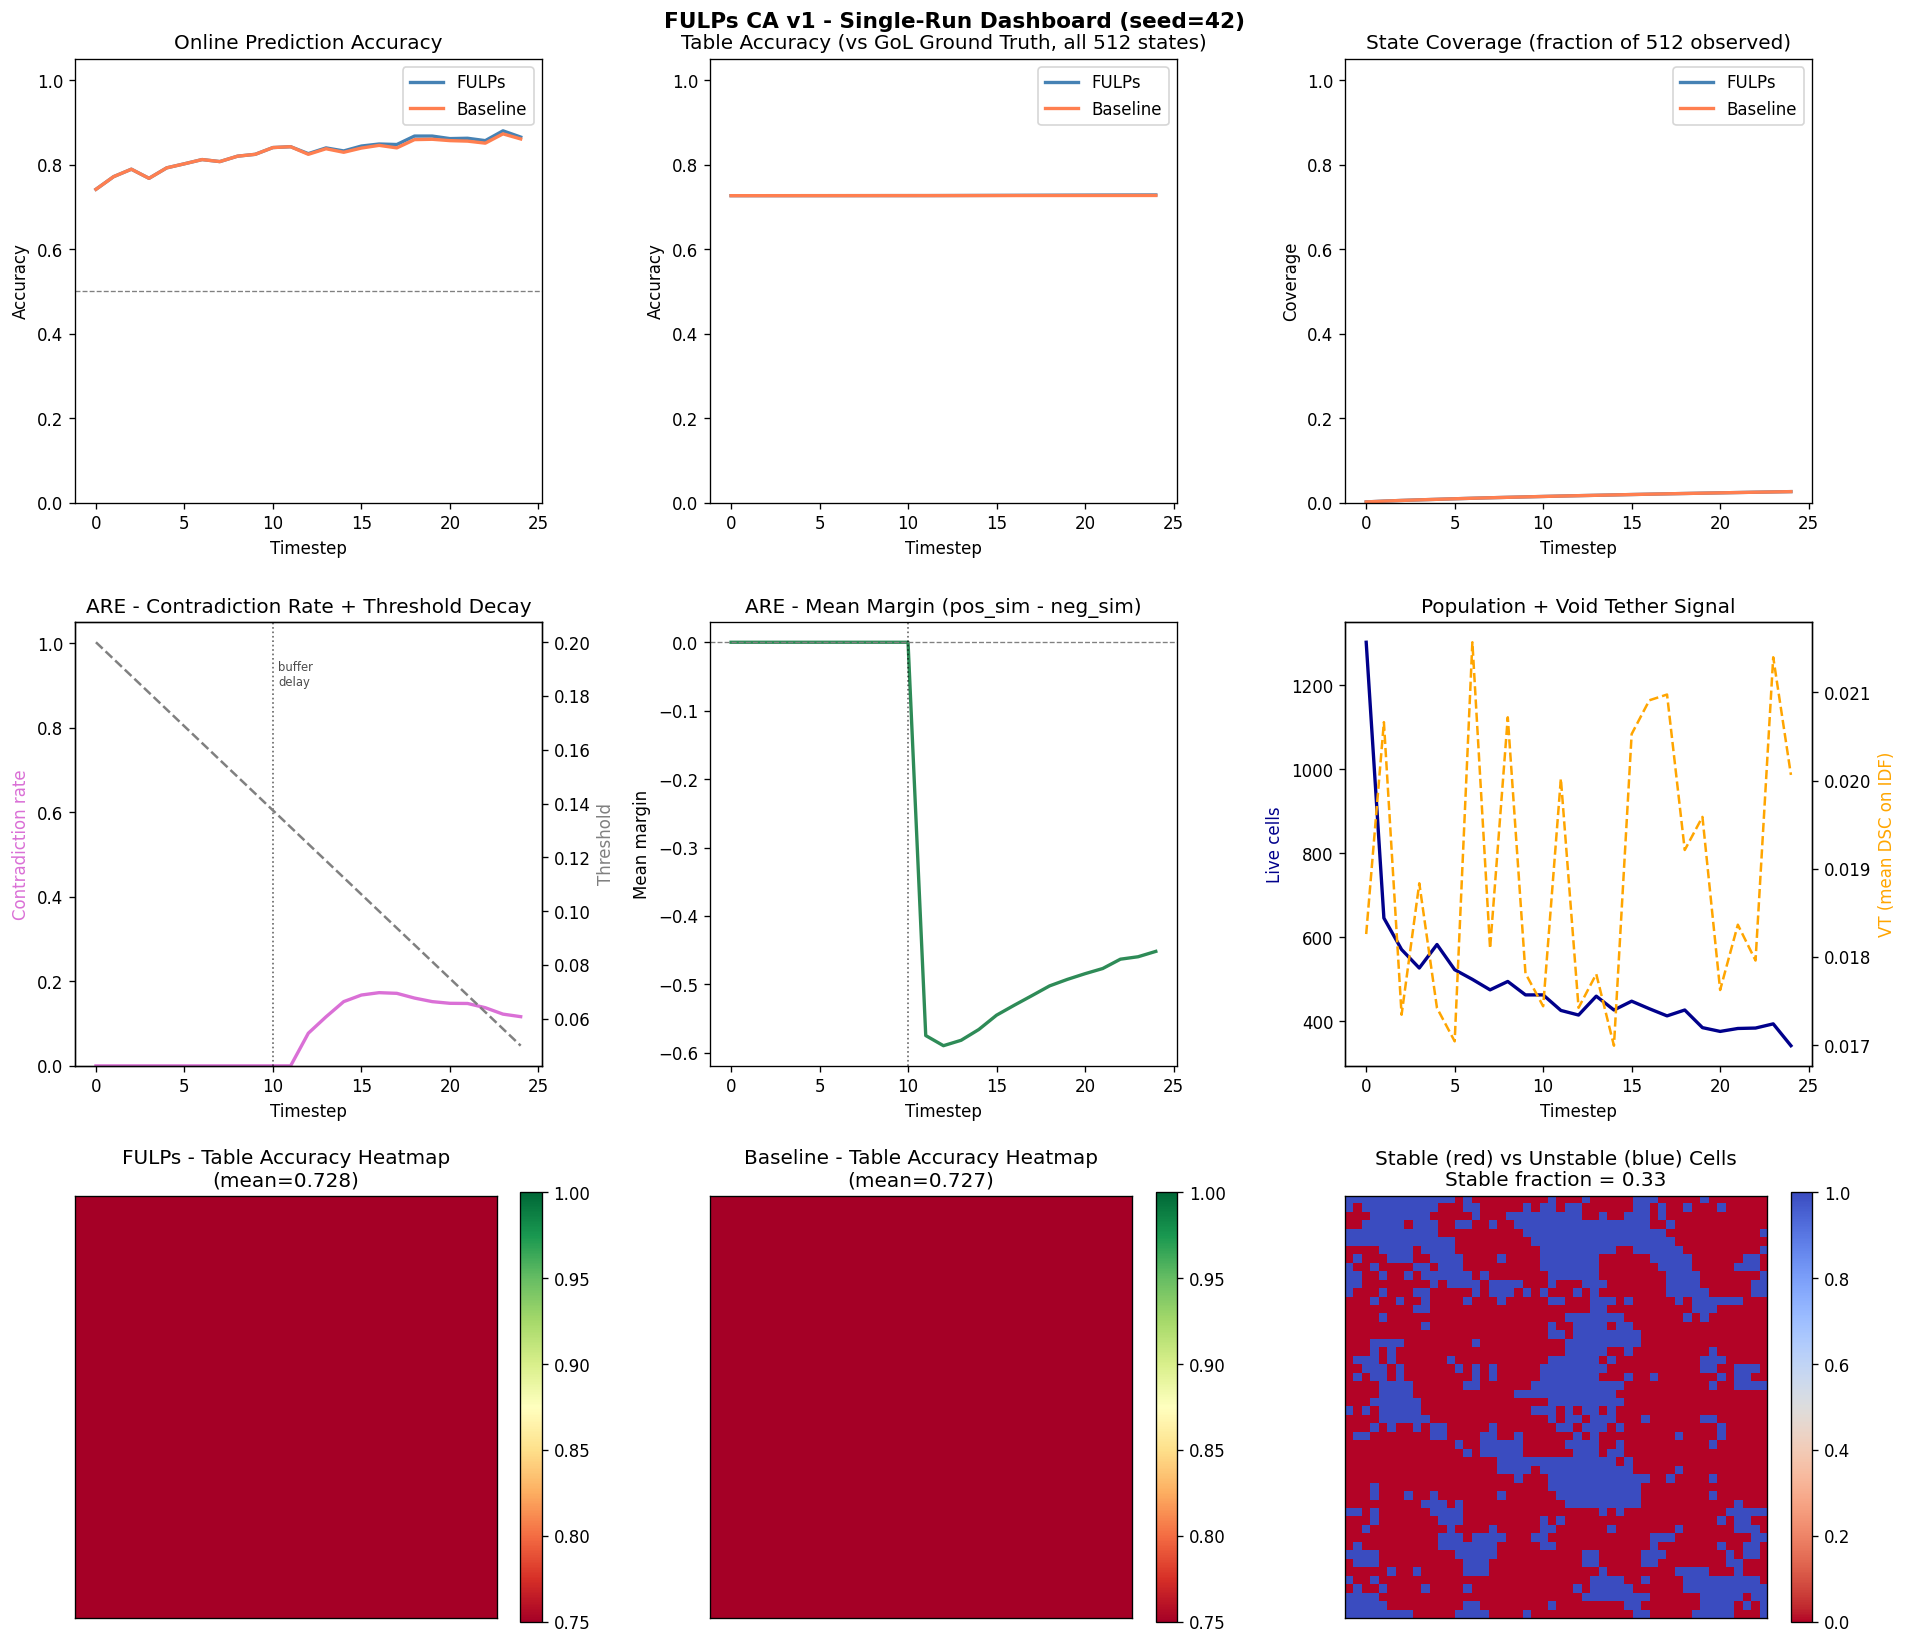

Saved: /content/fulps_ca_single_run.png


In [ ]:
# ── Cell 12: Single-Run Dashboard ────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle('FULPs CA v1 - Single-Run Dashboard (seed=42)',
             fontsize=13, fontweight='bold')

T = list(range(N_TIMESTEPS))

# ── Row 1: Accuracy and Coverage ─────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(T, single_history['fulps_online_acc'], color='steelblue', label='FULPs', lw=2)
ax1.plot(T, single_history['base_online_acc'],  color='coral',     label='Baseline', lw=2)
ax1.set_title('Online Prediction Accuracy')
ax1.set_xlabel('Timestep'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.set_ylim(0, 1.05)
ax1.axhline(0.5, color='gray', linestyle='--', lw=0.8)

ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(T, single_history['fulps_table_acc'], color='steelblue', label='FULPs', lw=2)
ax2.plot(T, single_history['base_table_acc'],  color='coral',     label='Baseline', lw=2)
ax2.set_title('Table Accuracy (vs GoL Ground Truth, all 512 states)')
ax2.set_xlabel('Timestep'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.set_ylim(0, 1.05)

ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(T, single_history['fulps_coverage'], color='steelblue', label='FULPs', lw=2)
ax3.plot(T, single_history['base_coverage'],  color='coral',     label='Baseline', lw=2)
ax3.set_title('State Coverage (fraction of 512 observed)')
ax3.set_xlabel('Timestep'); ax3.set_ylabel('Coverage')
ax3.legend(); ax3.set_ylim(0, 1.05)

# ── Row 2: ARE Dynamics ────────────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
ax4b = ax4.twinx()
ax4.plot(T, single_history['contra_rate'], color='orchid', lw=2, label='Contra rate')
ax4b.plot(T, single_history['threshold'], color='gray', linestyle='--', lw=1.5,
          label='Threshold')
ax4.axvline(BUFFER_DELAY, color='black', linestyle=':', lw=1, alpha=0.6)
ax4.text(BUFFER_DELAY + 0.3, 0.9, f'buffer\ndelay', fontsize=7, color='black', alpha=0.7)
ax4.set_title('ARE - Contradiction Rate + Threshold Decay')
ax4.set_xlabel('Timestep')
ax4.set_ylabel('Contradiction rate', color='orchid')
ax4b.set_ylabel('Threshold', color='gray')
ax4.set_ylim(0, 1.05)

ax5 = fig.add_subplot(3, 3, 5)
ax5.plot(T, single_history['margin_mean'], color='seagreen', lw=2)
ax5.axhline(0, color='gray', linestyle='--', lw=0.8)
ax5.axvline(BUFFER_DELAY, color='black', linestyle=':', lw=1, alpha=0.6)
ax5.set_title('ARE - Mean Margin (pos_sim - neg_sim)')
ax5.set_xlabel('Timestep'); ax5.set_ylabel('Mean margin')

ax6 = fig.add_subplot(3, 3, 6)
ax6b = ax6.twinx()
ax6.plot(T, single_history['population'], color='darkblue', lw=2, label='Population')
ax6b.plot(T, single_history['vt_signal'], color='orange', linestyle='--', lw=1.5,
          label='VT signal')
ax6.set_title('Population + Void Tether Signal')
ax6.set_xlabel('Timestep')
ax6.set_ylabel('Live cells', color='darkblue')
ax6b.set_ylabel('VT (mean DSC on IDF)', color='orange')

# ── Row 3: Spatial Heatmaps ────────────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
im7 = ax7.imshow(single_final['f_tacc_g'], cmap='RdYlGn', vmin=0.75, vmax=1.0)
ax7.set_title(f'FULPs - Table Accuracy Heatmap\n(mean={single_results["fulps_final_table_acc"]:.3f})')
plt.colorbar(im7, ax=ax7, fraction=0.046)
ax7.set_xticks([]); ax7.set_yticks([])

ax8 = fig.add_subplot(3, 3, 8)
im8 = ax8.imshow(single_final['b_tacc_g'], cmap='RdYlGn', vmin=0.75, vmax=1.0)
ax8.set_title(f'Baseline - Table Accuracy Heatmap\n(mean={single_results["base_final_table_acc"]:.3f})')
plt.colorbar(im8, ax=ax8, fraction=0.046)
ax8.set_xticks([]); ax8.set_yticks([])

ax9 = fig.add_subplot(3, 3, 9)
im9 = ax9.imshow(single_final['stable_mask'].astype(float),
                 cmap='coolwarm_r', vmin=0, vmax=1)
ax9.set_title(f'Stable (red) vs Unstable (blue) Cells\n'
              f'Stable fraction = {single_results["stable_fraction"]:.2f}')
plt.colorbar(im9, ax=ax9, fraction=0.046)
ax9.set_xticks([]); ax9.set_yticks([])

plt.tight_layout()
path = os.path.join(OUT_DIR, 'fulps_ca_single_run.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [ ]:
# ── Cell 13: Multi-Run Study (30 runs) ───────────────────────────────────────
# Verify single-run health checks PASS before running this cell.
# Batch CSVs save every 5 runs. Download from Colab file panel as they appear.
# The VoidStabilizer and DSC_THRESHOLD are reused across all runs (trained once above).
print('=' * 60)
print('STARTING 30-RUN STUDY')
print('=' * 60)
print(f'Runs: {N_RUNS}  |  Seeds: {BASE_SEED}-{BASE_SEED+N_RUNS-1}')
print(f'Batch CSVs every {BATCH_SIZE} runs. Download from Colab file panel.\n')

METRIC_KEYS = [
    'fulps_final_table_acc',  'base_final_table_acc',
    'fulps_final_coverage',   'base_final_coverage',
    'fulps_final_perstate',   'base_final_perstate',
    'fulps_stable_tacc',      'base_stable_tacc',
    'fulps_unstable_tacc',    'base_unstable_tacc',
    'fulps_stable_coverage',  'base_stable_coverage',
    'fulps_unstable_coverage','base_unstable_coverage',
    'fulps_stable_perstate',  'base_stable_perstate',
    'fulps_unstable_perstate','base_unstable_perstate',
    'stable_fraction',        'mean_contra_rate',
]

all_results = {k: [] for k in METRIC_KEYS}
all_rows    = []

for run_idx in range(N_RUNS):
    seed = BASE_SEED + run_idx
    print(f'Run {run_idx+1:2d}/{N_RUNS}  (seed={seed})', end=' ... ')

    _, results, _ = run_simulation(
        seed=seed,
        void_model=void_model,
        idf=IDF,
        dsc_threshold=DSC_THRESHOLD,
        is_single_run=False,
        verbose=False,
    )

    for k in METRIC_KEYS:
        all_results[k].append(results.get(k, np.nan))

    row = {'run': run_idx + 1, 'seed': seed}
    row.update(results)
    all_rows.append(row)

    if (run_idx + 1) % BATCH_SIZE == 0:
        batch_num  = (run_idx + 1) // BATCH_SIZE
        batch_df   = pd.DataFrame(all_rows[-BATCH_SIZE:])
        batch_path = os.path.join(OUT_DIR, f'results_batch_{batch_num}.csv')
        batch_df.to_csv(batch_path, index=False)
        f_t = np.nanmean(all_results['fulps_final_table_acc'][-BATCH_SIZE:])
        b_t = np.nanmean(all_results['base_final_table_acc'][-BATCH_SIZE:])
        print(f'\n  Batch {batch_num} saved -> {batch_path}')
        print(f'  Batch mean  fulps_tacc={f_t:.3f}  base_tacc={b_t:.3f}')
    else:
        f_t = results['fulps_final_table_acc']
        b_t = results['base_final_table_acc']
        print(f'f_tacc={f_t:.3f}  b_tacc={b_t:.3f}')

full_df   = pd.DataFrame(all_rows)
full_path = os.path.join(OUT_DIR, 'results_30runs_ca.csv')
full_df.to_csv(full_path, index=False)
print(f'\nFull CSV saved -> {full_path}')
print('Download from the Colab file panel.')

STARTING 30-RUN STUDY
Runs: 30  |  Seeds: 42-71
Batch CSVs every 5 runs. Download from Colab file panel.

Run  1/30  (seed=42) ... f_tacc=0.728  b_tacc=0.727
Run  2/30  (seed=43) ... f_tacc=0.728  b_tacc=0.727
Run  3/30  (seed=44) ... f_tacc=0.728  b_tacc=0.727
Run  4/30  (seed=45) ... f_tacc=0.728  b_tacc=0.727
Run  5/30  (seed=46) ... 
  Batch 1 saved -> /content/results_batch_1.csv
  Batch mean  fulps_tacc=0.728  base_tacc=0.727
Run  6/30  (seed=47) ... f_tacc=0.728  b_tacc=0.727
Run  7/30  (seed=48) ... f_tacc=0.728  b_tacc=0.727
Run  8/30  (seed=49) ... f_tacc=0.728  b_tacc=0.727
Run  9/30  (seed=50) ... f_tacc=0.728  b_tacc=0.727
Run 10/30  (seed=51) ... 
  Batch 2 saved -> /content/results_batch_2.csv
  Batch mean  fulps_tacc=0.728  base_tacc=0.727
Run 11/30  (seed=52) ... f_tacc=0.728  b_tacc=0.727
Run 12/30  (seed=53) ... f_tacc=0.728  b_tacc=0.727
Run 13/30  (seed=54) ... f_tacc=0.728  b_tacc=0.727
Run 14/30  (seed=55) ... f_tacc=0.728  b_tacc=0.727
Run 15/30  (seed=56) ... 


In [ ]:
# ── Cell 14: Statistical Summary ─────────────────────────────────────────────
print('=' * 60)
print('30-RUN STATISTICAL SUMMARY — FULPs CA v1')
print('=' * 60)


def summarise(key):
    a = np.array([v for v in all_results[key] if not np.isnan(v)])
    if len(a) == 0:
        return np.nan, np.nan, np.nan
    ci = 1.96 * a.std() / np.sqrt(len(a))
    return a.mean(), a.std(), ci


print(f"\n  {'Metric':<34} {'Mean':>7} {'SD':>7} {'95% CI':>10}")
print('  ' + '-' * 62)
for k in METRIC_KEYS:
    m, s, ci = summarise(k)
    if not np.isnan(m):
        print(f'  {k:<34} {m:>7.3f} {s:>7.3f}  +-{ci:>6.3f}')


def safe_arr(key):
    return np.array([v for v in all_results[key] if not np.isnan(v)])


def cohens_d(a, b):
    pooled = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 1e-9 else np.nan


print('\n── Hypothesis Tests ───────────────────────────────────────')

# Hyp A + B: Stable vs unstable table accuracy (FULPs)
f_stab = safe_arr('fulps_stable_tacc')
f_unst = safe_arr('fulps_unstable_tacc')
if len(f_stab) > 2 and len(f_unst) > 2:
    t_ab, p_ab = stats.ttest_ind(f_stab, f_unst)
    d_ab = cohens_d(f_stab, f_unst)
    print(f'\n  Hyp A+B -- FULPs stable vs unstable table accuracy')
    print(f'    stable mu={f_stab.mean():.3f}  unstable mu={f_unst.mean():.3f}')
    print(f'    t={t_ab:.3f}  p={p_ab:.4f}  Cohen d={d_ab:.3f}')
    interp = 'SUPPORTED' if p_ab < 0.05 and f_stab.mean() > f_unst.mean() else 'NOT SUPPORTED'
    print(f'    -> {interp}')

# Hyp C: Unstable coverage > stable coverage
f_scov = safe_arr('fulps_stable_coverage')
f_ucov = safe_arr('fulps_unstable_coverage')
if len(f_scov) > 2 and len(f_ucov) > 2:
    t_cov, p_cov = stats.ttest_ind(f_ucov, f_scov)
    d_cov = cohens_d(f_ucov, f_scov)
    print(f'\n  Hyp C (coverage) -- unstable > stable coverage (FULPs)')
    print(f'    unstable mu={f_ucov.mean():.3f}  stable mu={f_scov.mean():.3f}')
    print(f'    t={t_cov:.3f}  p={p_cov:.4f}  Cohen d={d_cov:.3f}')
    interp = 'SUPPORTED' if p_cov < 0.05 and f_ucov.mean() > f_scov.mean() else 'NOT SUPPORTED'
    print(f'    -> {interp}')

# Hyp C: Per-state accuracy - does FULPs attenuate the unstable penalty vs baseline?
f_ups = safe_arr('fulps_unstable_perstate')
b_ups = safe_arr('base_unstable_perstate')
if len(f_ups) > 2 and len(b_ups) > 2:
    t_ps, p_ps = stats.ttest_ind(f_ups, b_ups)
    d_ps = cohens_d(f_ups, b_ups)
    print(f'\n  Hyp C (per-state acc) -- FULPs vs Baseline in unstable cells')
    print(f'    FULPs mu={f_ups.mean():.3f}  Baseline mu={b_ups.mean():.3f}')
    print(f'    t={t_ps:.3f}  p={p_ps:.4f}  Cohen d={d_ps:.3f}')
    interp = 'SUPPORTED (FULPs retains higher per-state acc in unstable)' \
             if p_ps < 0.05 and f_ups.mean() > b_ups.mean() else 'NOT SUPPORTED'
    print(f'    -> {interp}')

# FULPs vs Baseline overall table accuracy
f_tacc = safe_arr('fulps_final_table_acc')
b_tacc = safe_arr('base_final_table_acc')
if len(f_tacc) > 2 and len(b_tacc) > 2:
    t_main, p_main = stats.ttest_ind(f_tacc, b_tacc)
    d_main = cohens_d(f_tacc, b_tacc)
    print(f'\n  FULPs vs Baseline -- overall final table accuracy')
    print(f'    FULPs mu={f_tacc.mean():.3f}  Baseline mu={b_tacc.mean():.3f}')
    print(f'    t={t_main:.3f}  p={p_main:.4f}  Cohen d={d_main:.3f}')

# Degradation gap: FULPs vs Baseline loss from stable -> unstable
f_drop = safe_arr('fulps_stable_tacc') - safe_arr('fulps_unstable_tacc')
b_drop = safe_arr('base_stable_tacc')  - safe_arr('base_unstable_tacc')
f_drop = f_drop[~np.isnan(f_drop)]
b_drop = b_drop[~np.isnan(b_drop)]
if len(f_drop) > 2 and len(b_drop) > 2:
    t_drop, p_drop = stats.ttest_ind(f_drop, b_drop)
    d_drop = cohens_d(f_drop, b_drop)
    print(f'\n  Degradation gap (stable->unstable): FULPs vs Baseline')
    print(f'    FULPs drop mu={f_drop.mean():.3f}  Baseline drop mu={b_drop.mean():.3f}')
    print(f'    t={t_drop:.3f}  p={p_drop:.4f}  Cohen d={d_drop:.3f}')
    print(f'    (negative t = FULPs degrades less -- aligns with Hyp C hope)')

30-RUN STATISTICAL SUMMARY — FULPs CA v1

  Metric                                Mean      SD     95% CI
  --------------------------------------------------------------
  fulps_final_table_acc                0.728   0.000  +- 0.000
  base_final_table_acc                 0.727   0.000  +- 0.000
  fulps_final_coverage                 0.028   0.002  +- 0.001
  base_final_coverage                  0.028   0.002  +- 0.001
  fulps_final_perstate                 0.783   0.009  +- 0.003
  base_final_perstate                  0.749   0.012  +- 0.004
  fulps_stable_tacc                    0.727   0.000  +- 0.000
  base_stable_tacc                     0.727   0.000  +- 0.000
  fulps_unstable_tacc                  0.729   0.000  +- 0.000
  base_unstable_tacc                   0.727   0.000  +- 0.000
  stable_fraction                      0.304   0.045  +- 0.016
  mean_contra_rate                     0.088   0.012  +- 0.004

── Hypothesis Tests ───────────────────────────────────────

  Hyp A+B -

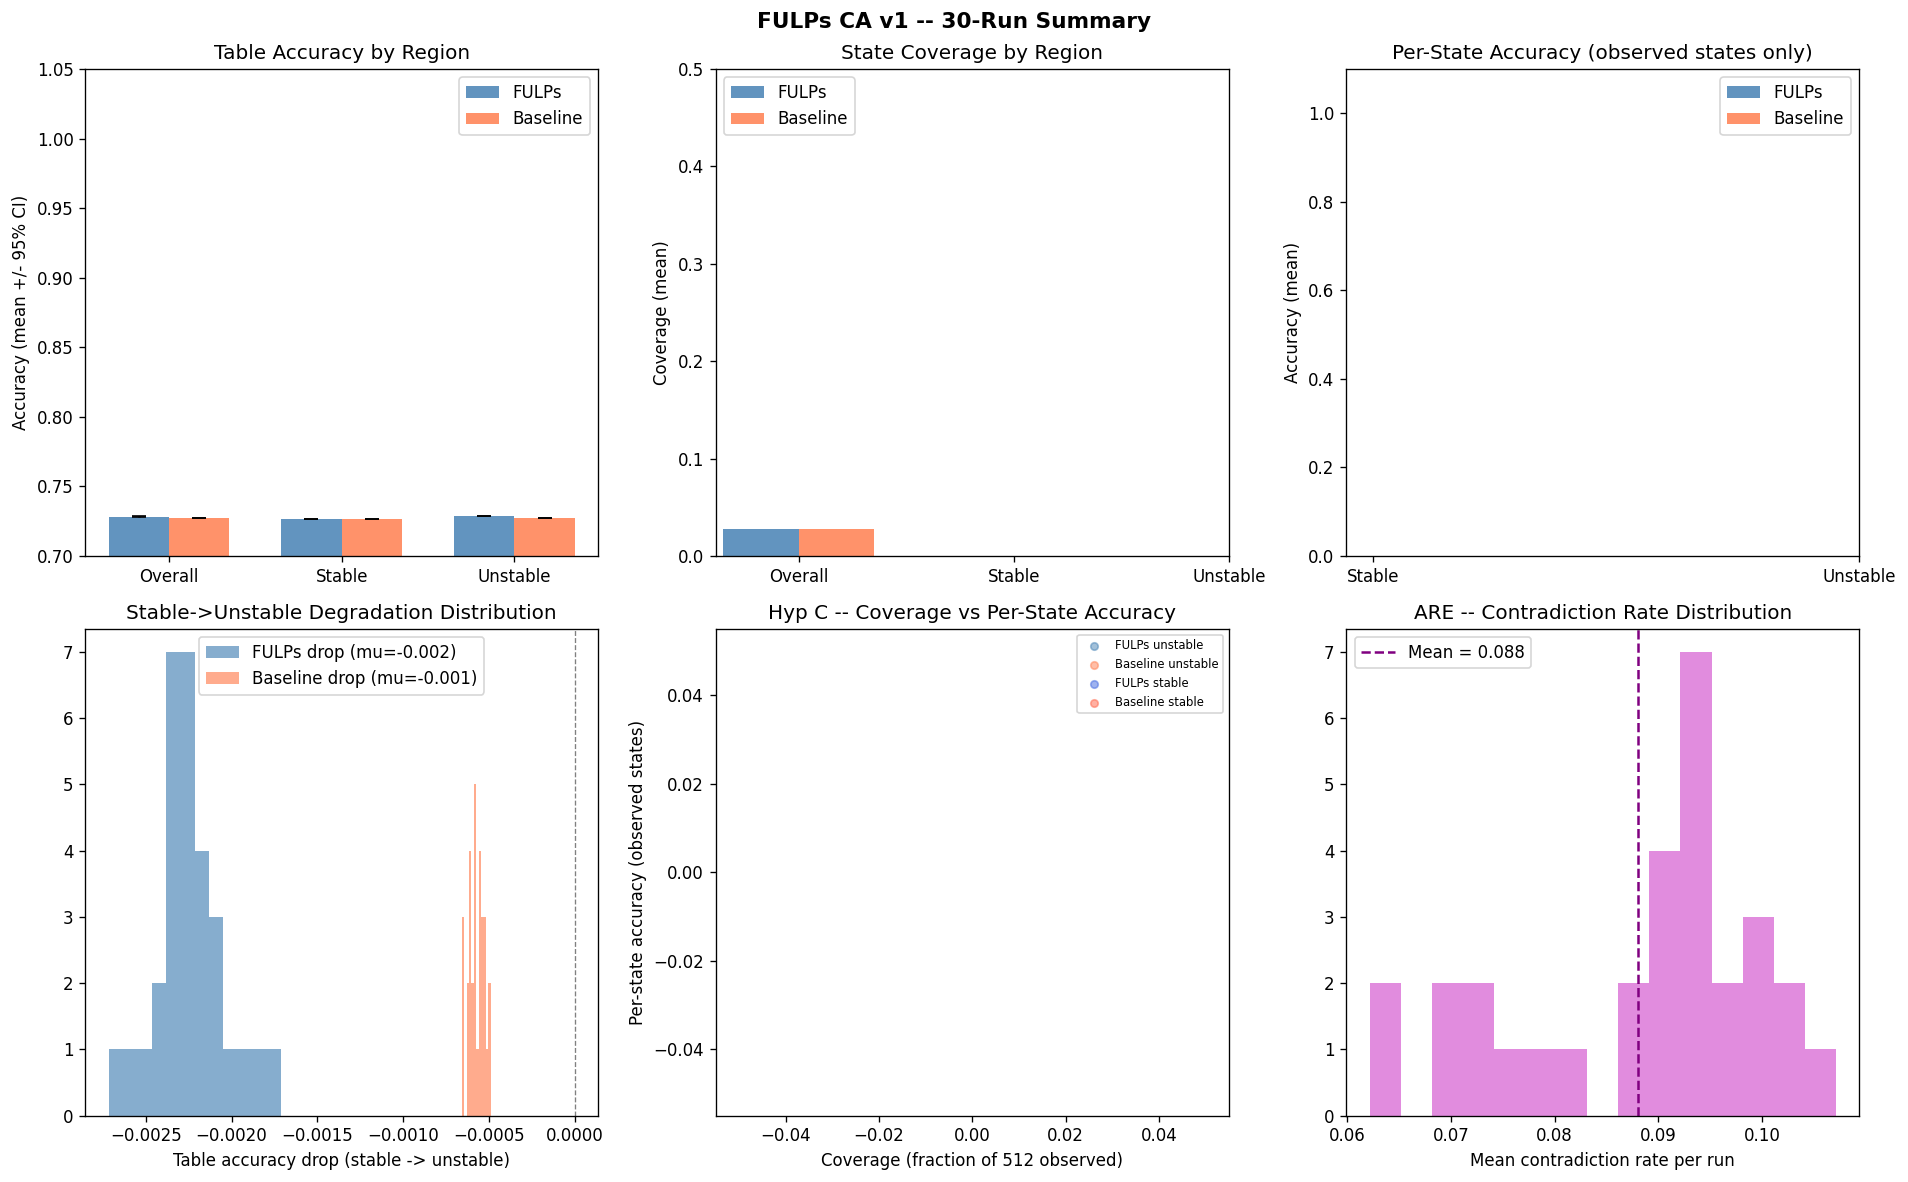

Multi-run chart saved -> /content/fulps_ca_multirun.png
Full CSV              -> /content/results_30runs_ca.csv
Download both from the Colab file panel.


In [ ]:
# ── Cell 15: Multi-Run Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('FULPs CA v1 -- 30-Run Summary', fontsize=13, fontweight='bold')

def safe_mean(key):  return np.nanmean(all_results[key])
def safe_ci(key):    return 1.96 * np.nanstd(all_results[key]) / np.sqrt(N_RUNS)

# ── Grouped table accuracy bar chart ──────────────────────────────────────────
ax = axes[0, 0]
cats  = ['Overall', 'Stable', 'Unstable']
f_acc = [safe_mean('fulps_final_table_acc'), safe_mean('fulps_stable_tacc'),
         safe_mean('fulps_unstable_tacc')]
b_acc = [safe_mean('base_final_table_acc'),  safe_mean('base_stable_tacc'),
         safe_mean('base_unstable_tacc')]
f_ci  = [safe_ci('fulps_final_table_acc'),   safe_ci('fulps_stable_tacc'),
         safe_ci('fulps_unstable_tacc')]
b_ci  = [safe_ci('base_final_table_acc'),    safe_ci('base_stable_tacc'),
         safe_ci('base_unstable_tacc')]
x, w  = np.arange(3), 0.35
ax.bar(x - w/2, f_acc, w, yerr=f_ci, capsize=4, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_acc, w, yerr=b_ci, capsize=4, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylim(0.7, 1.05)
ax.set_title('Table Accuracy by Region'); ax.set_ylabel('Accuracy (mean +/- 95% CI)')
ax.legend()

# ── Coverage bar chart ────────────────────────────────────────────────────────
ax = axes[0, 1]
f_cov = [safe_mean('fulps_final_coverage'),   safe_mean('fulps_stable_coverage'),
         safe_mean('fulps_unstable_coverage')]
b_cov = [safe_mean('base_final_coverage'),    safe_mean('base_stable_coverage'),
         safe_mean('base_unstable_coverage')]
ax.bar(x - w/2, f_cov, w, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x + w/2, b_cov, w, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylim(0, 0.5)
ax.set_title('State Coverage by Region'); ax.set_ylabel('Coverage (mean)')
ax.legend()

# ── Per-state accuracy bar chart ──────────────────────────────────────────────
ax = axes[0, 2]
x2   = np.arange(2)
cats2 = ['Stable', 'Unstable']
f_ps  = [safe_mean('fulps_stable_perstate'), safe_mean('fulps_unstable_perstate')]
b_ps  = [safe_mean('base_stable_perstate'),  safe_mean('base_unstable_perstate')]
ax.bar(x2 - w/2, f_ps, w, label='FULPs',    color='steelblue', alpha=0.85)
ax.bar(x2 + w/2, b_ps, w, label='Baseline', color='coral',     alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(cats2)
ax.set_ylim(0, 1.1)
ax.set_title('Per-State Accuracy (observed states only)')
ax.set_ylabel('Accuracy (mean)'); ax.legend()

# ── Stable->Unstable degradation distribution ──────────────────────────────────
ax = axes[1, 0]
f_drop = np.array(all_results['fulps_stable_tacc']) - np.array(all_results['fulps_unstable_tacc'])
b_drop = np.array(all_results['base_stable_tacc'])  - np.array(all_results['base_unstable_tacc'])
f_drop = f_drop[~np.isnan(f_drop)]; b_drop = b_drop[~np.isnan(b_drop)]
if len(f_drop) > 0:
    ax.hist(f_drop, bins=12, alpha=0.65, color='steelblue',
            label=f'FULPs drop (mu={f_drop.mean():.3f})')
if len(b_drop) > 0:
    ax.hist(b_drop, bins=12, alpha=0.65, color='coral',
            label=f'Baseline drop (mu={b_drop.mean():.3f})')
ax.axvline(0, color='gray', linestyle='--', lw=0.8)
ax.set_xlabel('Table accuracy drop (stable -> unstable)')
ax.set_title('Stable->Unstable Degradation Distribution')
ax.legend()

# ── Coverage vs per-state accuracy scatter (Hyp C) ────────────────────────────
ax = axes[1, 1]
for k_cov, k_ps, col, lbl in [
    ('fulps_unstable_coverage', 'fulps_unstable_perstate', 'steelblue', 'FULPs unstable'),
    ('base_unstable_coverage',  'base_unstable_perstate',  'coral',     'Baseline unstable'),
    ('fulps_stable_coverage',   'fulps_stable_perstate',   'royalblue', 'FULPs stable'),
    ('base_stable_coverage',    'base_stable_perstate',    'tomato',    'Baseline stable'),
]:
    xv = np.array(all_results[k_cov])
    yv = np.array(all_results[k_ps])
    mask = ~(np.isnan(xv) | np.isnan(yv))
    ax.scatter(xv[mask], yv[mask], color=col, alpha=0.5, s=20, label=lbl)
ax.set_xlabel('Coverage (fraction of 512 observed)')
ax.set_ylabel('Per-state accuracy (observed states)')
ax.set_title('Hyp C -- Coverage vs Per-State Accuracy')
ax.legend(fontsize=7)

# ── Contradiction rate distribution ────────────────────────────────────────────
ax = axes[1, 2]
contra = np.array(all_results['mean_contra_rate'])
contra = contra[~np.isnan(contra)]
if len(contra) > 0:
    ax.hist(contra, bins=15, color='orchid', alpha=0.8)
    ax.axvline(contra.mean(), color='purple', linestyle='--', lw=1.5,
               label=f'Mean = {contra.mean():.3f}')
ax.set_xlabel('Mean contradiction rate per run')
ax.set_title('ARE -- Contradiction Rate Distribution')
ax.legend()

plt.tight_layout()
mr_path = os.path.join(OUT_DIR, 'fulps_ca_multirun.png')
plt.savefig(mr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Multi-run chart saved -> {mr_path}')
print(f'Full CSV              -> {full_path}')
print('Download both from the Colab file panel.')